In [2]:
# 先整合多段结果文件，产出一个供后续 cell 复用的 merged JSON
import json
from pathlib import Path

SOURCE_RESULTS_PATH = Path("/root/skill/results/rq1/0064_0066_0072_minimax-cn-MiniMax-M2-5.json")
_MERGED_RESULTS_PATH = Path("/tmp/0064_0066_0072_minimax-cn-MiniMax-M2-5.merged.json")

with SOURCE_RESULTS_PATH.open("r", encoding="utf-8") as f:
    _runs = json.load(f)

if isinstance(_runs, dict):
    _merged = _runs
else:
    _tasks = []
    _efficiency = {}
    _per_task = []
    _judge_summary = []

    for _run in _runs:
        _tasks.extend(_run.get("tasks") or [])
        _run_eff = (_run.get("efficiency") or {}).copy()
        _per_task.extend(_run_eff.pop("per_task", []) or [])
        for _key, _value in _run_eff.items():
            if isinstance(_value, (int, float)):
                _efficiency[_key] = _efficiency.get(_key, 0) + _value
            else:
                _efficiency[_key] = _value
        _judge_summary.extend(_run.get("judge_summary") or [])

    _efficiency["per_task"] = _per_task
    _merged = {
        "model": (_runs[0] or {}).get("model", "unknown"),
        "benchmark_version": (_runs[0] or {}).get("benchmark_version", ""),
        "run_id": "0064_0066_0072",
        "timestamp": max((_run.get("timestamp") or 0) for _run in _runs),
        "suite": "merged",
        "runs_per_task": 1,
        "max_task_attempts": max((_run.get("max_task_attempts") or 0) for _run in _runs),
        "retry_policies": (_runs[0] or {}).get("retry_policies", {}),
        "tasks": _tasks,
        "efficiency": _efficiency,
        "judge_summary": _judge_summary,
    }

with _MERGED_RESULTS_PATH.open("w", encoding="utf-8") as f:
    json.dump(_merged, f, ensure_ascii=False, indent=2)

RESULTS_PATH_MINIMAX2_5 = str(_MERGED_RESULTS_PATH)
RESULTS_PATH_GPT5_3 = "/root/skill/results/rq1/0061_autodl-gpt-5-3-codex.json"
print(f"Merged {len(_runs) if isinstance(_runs, list) else 1} run(s) into {RESULTS_PATH_MINIMAX2_5}")
print(f"Total tasks after merge: {len(_merged.get('tasks', []))}")


Merged 4 run(s) into /tmp/0064_0066_0072_minimax-cn-MiniMax-M2-5.merged.json
Total tasks after merge: 23


In [ ]:
# MiniMax-M2.5	
# 价格(会员价)：
# 输入：
# ￥1.260 / M token
# 输入(缓存命中)：
# ￥0.252 / M token
# 输出：
# ￥5.040 / M token

# GPT5_3 价格：
# 输入：
# 6.125 元 / M token
# 输入(缓存命中)：
# 1.230 元 / M token
# 输出：
# 49.000 元 / M token

In [4]:
# 每次 attempt 的 score + token 使用，以及单次 vs 多次 attempt 的对比
import json
from pathlib import Path

import pandas as pd

# 结果文件路径：默认使用上方预处理 cell 产出的 merged JSON
# RESULTS_PATH = globals().get("RESULTS_PATH", "/tmp/0064_0066_0072_minimax-cn-MiniMax-M2-5.merged.json")
RESULTS_PATH = RESULTS_PATH_GPT5_3
with open(RESULTS_PATH, "r", encoding="utf-8") as f:
    _data = json.load(f)

_tasks = _data.get("tasks", [])
_efficiency = _data.get("efficiency", {}) or {}
_per_task_eff = {x["task_id"]: x for x in (_efficiency.get("per_task") or [])}

# 1) 每次 attempt 的明细：score + tokens
attempt_rows = []

for t in _tasks:
    task_id = t.get("task_id", "")
    name = (t.get("frontmatter") or {}).get("name") or task_id
    attempts = t.get("attempts") or []

    for a in attempts:
        g = a.get("grading") or {}
        ex = a.get("execution") or {}
        u = (ex.get("usage") or {}) or (a.get("usage") or {})

        attempt_rows.append({
            "task_id": task_id,
            "name": name,
            "attempt": int(a.get("attempt", 0)),
            "score": float(g.get("score", 0)),
            "max_score": float(g.get("max_score", 1) or 1),
            "execution_time": float(ex.get("execution_time", 0)),
            "status": ex.get("status", ""),
            "input_tokens": float(u.get("input_tokens") or 0),
            "output_tokens": float(u.get("output_tokens") or 0),
            "total_tokens": float(u.get("total_tokens") or 0),
        })

if attempt_rows:
    df_attempts = pd.DataFrame(attempt_rows)
    df_attempts["score_pct"] = (df_attempts["score"] / df_attempts["max_score"].replace(0, 1) * 100).round(1)
    display(df_attempts[[
        "task_id", "attempt", "score", "max_score", "score_pct",
        "execution_time", "status",
        "input_tokens", "output_tokens", "total_tokens",
    ]])
else:
    print("没有 attempt 明细数据。")

# 2) 对比：仅第一次 attempt vs 允许多次 attempt 后的最终结果

# 每个任务取「仅第一次 attempt」的 score + token（区分 input/output）
first_attempt_scores = []
first_input_tokens = []
first_output_tokens = []
first_total_tokens_incl_cache = []

# 每个任务取「允许多次 attempt 后的最终」score 和「全部 attempt 累计」token
final_scores = []
all_input_tokens = []
all_output_tokens = []
all_total_tokens_incl_cache = []

for t in _tasks:
    attempts = t.get("attempts") or []
    comp = t.get("completion") or {}

    # 最终得分（多次 attempt 下的结果）
    final_scores.append(float(comp.get("score", 0)))

    task_input_sum = 0.0
    task_output_sum = 0.0
    task_total_sum = 0.0
    first_score = None
    first_in = None
    first_out = None
    first_total = None

    for a in attempts:
        ex = a.get("execution") or {}
        u = (ex.get("usage") or {}) or (a.get("usage") or {})

        in_tok = float(u.get("input_tokens", u.get("input", 0)) or 0)
        out_tok = float(u.get("output_tokens", u.get("output", 0)) or 0)
        total_tok = float(u.get("total_tokens", u.get("totalTokens", 0)) or 0)

        task_input_sum += in_tok
        task_output_sum += out_tok
        task_total_sum += total_tok

        if first_total is None:
            first_in = in_tok
            first_out = out_tok
            first_total = total_tok
            g = a.get("grading") or {}
            first_score = float(g.get("score", 0))

    all_input_tokens.append(task_input_sum)
    all_output_tokens.append(task_output_sum)
    all_total_tokens_incl_cache.append(task_total_sum)

    first_attempt_scores.append(first_score if first_score is not None else 0.0)
    first_input_tokens.append(first_in if first_in is not None else 0.0)
    first_output_tokens.append(first_out if first_out is not None else 0.0)
    first_total_tokens_incl_cache.append(first_total if first_total is not None else 0.0)

n_tasks = len(_tasks)

# 汇总表：两行对比（显式区分 input/output 以及 total 是否含 cache）
summary = [
    {
        "场景": "仅第一次 attempt（不允许多次重试）",
        "任务数": n_tasks,
        "所有任务平均 score": sum(first_attempt_scores) / n_tasks if n_tasks else 0,
        "输入 token 总和（不含 cache）": sum(first_input_tokens),
        "输出 token 总和（不含 cache）": sum(first_output_tokens),
        "total_tokens 总和（一般含 cache）": sum(first_total_tokens_incl_cache),
    },
    {
        "场景": "允许多次 attempt（取最终得分，统计全部 attempt 的 token）",
        "任务数": n_tasks,
        "所有任务平均 score": sum(final_scores) / n_tasks if n_tasks else 0,
        "输入 token 总和（不含 cache）": sum(all_input_tokens),
        "输出 token 总和（不含 cache）": sum(all_output_tokens),
        "total_tokens 总和（一般含 cache）": sum(all_total_tokens_incl_cache),
    },
]

summary_df = pd.DataFrame(summary)
print("引入多次 attempt 前后对比（同一批任务，区分 input/output）：")
display(summary_df)


,task_id,attempt,score,max_score,score_pct,execution_time,status,input_tokens,output_tokens,total_tokens
0,task_00_sanity,1,1.0000,1.0,100.0,13.781354,success,9242.0,48.0,9290.0
1,task_01_calendar,1,1.0000,1.0,100.0,23.079594,success,9583.0,591.0,29502.0
2,task_02_stock,1,1.0000,1.0,100.0,40.967107,success,10028.0,1046.0,51266.0
3,task_03_blog,1,0.9250,1.0,92.5,35.760610,success,9703.0,1113.0,30912.0
4,task_03_blog,2,1.0000,1.0,100.0,2.983661,success,2779.0,999.0,47554.0
...,...,...,...,...,...,...,...,...,...,...
59,task_22_second_brain,2,0.5550,1.0,55.5,191.668645,timeout,37423.0,1284.0,376371.0
60,task_22_second_brain,3,0.6250,1.0,62.5,-0.001996,timeout,38938.0,962.0,241628.0
61,task_22_second_brain,4,0.9125,1.0,91.2,0.004199,timeout,52285.0,1334.0,347507.0
62,task_22_second_brain,5,0.9125,1.0,91.2,-288.435996,success,41060.0,197.0,51113.0


引入多次 attempt 前后对比（同一批任务，区分 input/output）：


,场景,任务数,所有任务平均 score,输入 token 总和（不含 cache）,输出 token 总和（不含 cache）,total_tokens 总和（一般含 cache）
0,仅第一次 attempt（不允许多次重试）,23,0.850899,343171.0,32679.0,2054442.0
1,允许多次 attempt（取最终得分，统计全部 attempt 的 token）,23,0.964261,656134.0,57136.0,5112816.0


,model,attempt,tasks,input_tokens,output_tokens,cache_read_tokens,cache_write_tokens,input_cost_cny,output_cost_cny,cache_read_cost_cny,cache_write_cost_cny,total_cost_cny,avg_cost_per_task_cny
0,GPT-5.3,1,23,343171.0,32679.0,1678592.0,0.0,2.1019,1.6013,2.0647,0.0000,5.7679,0.2508
1,GPT-5.3,2,13,128015.0,10727.0,920576.0,0.0,0.7841,0.5256,1.1323,0.0000,2.4420,0.1878
2,GPT-5.3,3,9,49768.0,3335.0,498304.0,0.0,0.3048,0.1634,0.6129,0.0000,1.0812,0.1201
3,GPT-5.3,4,7,67601.0,4235.0,703104.0,0.0,0.4141,0.2075,0.8648,0.0000,1.4864,0.2123
4,GPT-5.3,5,6,48258.0,3038.0,239872.0,0.0,0.2956,0.1489,0.2950,0.0000,0.7395,0.1232
5,GPT-5.3,6,6,19321.0,3122.0,340304.0,18794.0,0.1183,0.1530,0.4186,0.0000,0.6899,0.1150
6,MiniMax-M2.5,1,23,634431.0,27106.0,1190061.0,46367.0,1.3323,0.2277,0.2499,0.1217,1.9316,0.0840
7,MiniMax-M2.5,2,15,671028.0,21662.0,956402.0,118705.0,1.4092,0.1820,0.2008,0.3116,2.1036,0.1402
8,MiniMax-M2.5,3,14,426055.0,16176.0,772645.0,58940.0,0.8947,0.1359,0.1623,0.1547,1.3476,0.0963
9,MiniMax-M2.5,4,14,803742.0,16770.0,868574.0,20531.0,1.6879,0.1409,0.1824,0.0539,2.0650,0.1475


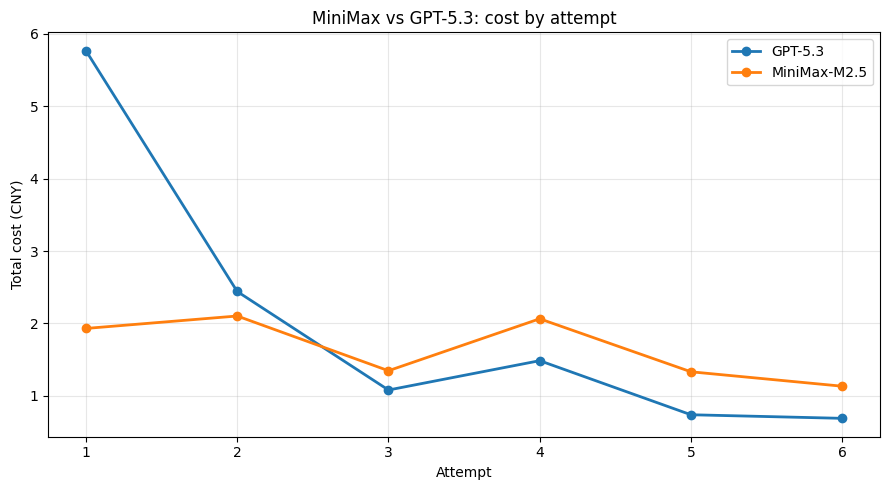

In [5]:
# 对比 MiniMax-M2.5 和 GPT-5.3 在不同 attempt 上的成本（人民币）
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

MINIMAX_STANDARD_PRICE_CNY_PER_MTOKEN = {
    "input_tokens": 2.1,
    "output_tokens": 8.4,
    "cache_read_tokens": 0.21,
    "cache_write_tokens": 2.625,
}
MINIMAX_MEMBER_PRICE_CNY_PER_MTOKEN = {
    "input_tokens": 1.260,
    "output_tokens": 5.040,
    "cache_read_tokens": 0.252,
    "cache_write_tokens": 1.260,
}
MINIMAX_PRICING_MODE = "member"  # one of: 'standard', 'member'
MINIMAX_PRICE_OPTIONS = {
    "standard": MINIMAX_STANDARD_PRICE_CNY_PER_MTOKEN,
    "member": MINIMAX_MEMBER_PRICE_CNY_PER_MTOKEN,
}
if MINIMAX_PRICING_MODE not in MINIMAX_PRICE_OPTIONS:
    raise ValueError(f"Unsupported MINIMAX_PRICING_MODE: {MINIMAX_PRICING_MODE}")
ACTIVE_MINIMAX_PRICE_CNY_PER_MTOKEN = MINIMAX_PRICE_OPTIONS[MINIMAX_PRICING_MODE]
GPT53_PRICE_CNY_PER_MTOKEN = {
    "input_tokens": 6.125,
    "output_tokens": 49.0,
    "cache_read_tokens": 1.230,
    "cache_write_tokens": 0.0,
}
PRICE_CNY_PER_MTOKEN = {
    "MiniMax-M2.5": ACTIVE_MINIMAX_PRICE_CNY_PER_MTOKEN,
    "GPT-5.3": GPT53_PRICE_CNY_PER_MTOKEN,
}

MODEL_RESULTS = {
    "MiniMax-M2.5": Path(RESULTS_PATH_MINIMAX2_5),
    "GPT-5.3": Path(RESULTS_PATH_GPT5_3),
}
print(f"MiniMax pricing mode: {MINIMAX_PRICING_MODE}")
print(f"MiniMax price table: {ACTIVE_MINIMAX_PRICE_CNY_PER_MTOKEN}")
print(f"GPT price table: {GPT53_PRICE_CNY_PER_MTOKEN}")

def _load_attempt_cost_rows(model_name, path):
    data = json.loads(path.read_text(encoding="utf-8"))
    prices = PRICE_CNY_PER_MTOKEN[model_name]
    rows = []

    for task in data.get("tasks") or []:
        for attempt in task.get("attempts") or []:
            usage = ((attempt.get("execution") or {}).get("usage") or attempt.get("usage") or {})
            input_tokens = float(usage.get("input_tokens") or 0)
            output_tokens = float(usage.get("output_tokens") or 0)
            cache_read_tokens = float(usage.get("cache_read_tokens") or 0)
            cache_write_tokens = float(usage.get("cache_write_tokens") or 0)

            rows.append({
                "model": model_name,
                "task_id": task.get("task_id", ""),
                "attempt": int(attempt.get("attempt") or 0),
                "input_tokens": input_tokens,
                "output_tokens": output_tokens,
                "cache_read_tokens": cache_read_tokens,
                "cache_write_tokens": cache_write_tokens,
                "input_cost_cny": input_tokens / 1_000_000 * prices["input_tokens"],
                "output_cost_cny": output_tokens / 1_000_000 * prices["output_tokens"],
                "cache_read_cost_cny": cache_read_tokens / 1_000_000 * prices["cache_read_tokens"],
                "cache_write_cost_cny": cache_write_tokens / 1_000_000 * prices["cache_write_tokens"],
            })

    return rows

cost_rows = []
for model_name, result_path in MODEL_RESULTS.items():
    cost_rows.extend(_load_attempt_cost_rows(model_name, result_path))

df_cost = pd.DataFrame(cost_rows)
df_cost["total_cost_cny"] = df_cost[[
    "input_cost_cny",
    "output_cost_cny",
    "cache_read_cost_cny",
    "cache_write_cost_cny",
]].sum(axis=1)

attempt_cost_summary = (
    df_cost.groupby(["model", "attempt"], as_index=False)
    .agg(
        tasks=("task_id", "nunique"),
        input_tokens=("input_tokens", "sum"),
        output_tokens=("output_tokens", "sum"),
        cache_read_tokens=("cache_read_tokens", "sum"),
        cache_write_tokens=("cache_write_tokens", "sum"),
        input_cost_cny=("input_cost_cny", "sum"),
        output_cost_cny=("output_cost_cny", "sum"),
        cache_read_cost_cny=("cache_read_cost_cny", "sum"),
        cache_write_cost_cny=("cache_write_cost_cny", "sum"),
        total_cost_cny=("total_cost_cny", "sum"),
    )
    .sort_values(["model", "attempt"])
)
attempt_cost_summary["avg_cost_per_task_cny"] = (
    attempt_cost_summary["total_cost_cny"] / attempt_cost_summary["tasks"]
)

display(
    attempt_cost_summary[[
        "model",
        "attempt",
        "tasks",
        "input_tokens",
        "output_tokens",
        "cache_read_tokens",
        "cache_write_tokens",
        "input_cost_cny",
        "output_cost_cny",
        "cache_read_cost_cny",
        "cache_write_cost_cny",
        "total_cost_cny",
        "avg_cost_per_task_cny",
    ]].round(4)
)

fig, ax = plt.subplots(figsize=(9, 5))
for model_name, grp in attempt_cost_summary.groupby("model"):
    ax.plot(grp["attempt"], grp["total_cost_cny"], marker="o", linewidth=2, label=model_name)

ax.set_title("MiniMax vs GPT-5.3: cost by attempt")
ax.set_xlabel("Attempt")
ax.set_ylabel("Total cost (CNY)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


# RQ1: Performance Analysis Plan

本 notebook 现在按 `chugao.md` 中 `9.1 RQ1: Performance` 的三层结构重新组织分析，直接对比：

- 小模型：`RESULTS_PATH_MINIMAX2_5 = str(_MERGED_RESULTS_PATH)`，即合并后的 `MiniMax-M2.5`
- 大模型：`RESULTS_PATH_GPT5_3 = "/root/skill/results/rq1/0061_autodl-gpt-5-3-codex.json"`



## 9.1.1 First-Attempt Gap

第一层先回答：大模型是否主要赢在“一次做对”。在共同 21 个任务上：

- `MiniMax-M2.5` first-attempt success = `7/21 = 33.3%`
- `GPT-5.3` first-attempt success = `10/21 = 47.6%`
- 首轮 success gap = **14.3 percentage points**

因此，这组数据里大模型确实存在明显的 first-attempt 优势，但优势规模属于“中等差距”，还不能单靠首轮结果判断最终差异会有多大。

## 9.1.2 Quantitative Gap Closure

第二层看反馈迭代之后，gap 是缩小还是扩大，以及扩大/缩小发生在哪些任务类型。

整体结果如下：

- `MiniMax-M2.5` final success = `8/21 = 38.1%`，相比首轮只增加 **1 个成功任务**，增幅 `+4.8pp`
- `GPT-5.3` final success = `16/21 = 76.2%`，相比首轮增加 **6 个成功任务**，增幅 `+28.6pp`
- 因而 success gap **没有收敛，反而从 14.3pp 扩大到 38.1pp**

这意味着：在当前 OpenClaw + validator feedback 设置下，iteration 并没有帮助小模型追平大模型；真正更能从 feedback 中获益的是 `GPT-5.3`。

从 `success@k` 看，差距的扩大过程也很清楚：

- `success@1`：MiniMax `33.3%`，GPT `47.6%`，gap `14.3pp`
- `success@2`：MiniMax `38.1%`，GPT `61.9%`，gap `23.8pp`
- `success@3`：MiniMax `38.1%`，GPT `71.4%`，gap `33.3pp`
- `success@4+`：MiniMax 停在 `38.1%`，GPT 达到 `76.2%`，gap 固定在 `38.1pp`

边际收益也非常不对称：

- `MiniMax-M2.5` 只有 **1 个任务** 在第 2 次 attempt 首次过关，之后没有新增成功
- `GPT-5.3` 的首次成功分布是：第 1 次 `10` 个，第 2 次 `3` 个，第 3 次 `2` 个，第 4 次 `1` 个
- 换言之，小模型的收益几乎在 **第 2 次 attempt** 就见顶；大模型在 **第 4 次 attempt** 前仍持续获得增益

跨任务类型看，也没有出现大面积的“gap closure”现象；更常见的是 GPT 在 retry 中新增通过，而 MiniMax 停留在高分但未过线状态：

- `research`：MiniMax `50.0% -> 50.0%`，GPT `50.0% -> 100.0%`
- `writing`：MiniMax `0.0% -> 0.0%`，GPT `0.0% -> 50.0%`
- `organization`：MiniMax `0.0% -> 0.0%`，GPT `0.0% -> 100.0%`
- `data_analysis`：MiniMax `0.0% -> 0.0%`，GPT `0.0% -> 100.0%`
- `complex`：MiniMax `0.0% -> 0.0%`，GPT `0.0% -> 100.0%`

唯一明确被 feedback 修复的小模型任务是 `task_21_openclaw_comprehension`：MiniMax 从 `0.9444` 提升到 `1.0`，说明当错误非常局部、反馈非常明确时，小模型确实可能完成补救。但这个现象在当前样本里是孤例，而不是主趋势。



In [6]:
# 依赖（如无则 pip install matplotlib pandas）
import json
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["font.sans-serif"] = ["DejaVu Sans", "SimHei", "Arial Unicode MS"]
matplotlib.rcParams["axes.unicode_minus"] = False


with open(RESULTS_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

model = data.get("model", "unknown")
run_id = data.get("run_id", "")
tasks = data.get("tasks", [])
efficiency = data.get("efficiency", {})

print(f"Model: {model}  Run: {run_id}   Tasks: {len(tasks)}")

Model: minimax-cn/MiniMax-M2.5  Run: 0064_0066_0072   Tasks: 23


In [7]:
# 解析：按 task 汇总 + 按 attempts 拆开每一轮
def parse_task(t):
    name = (t.get("frontmatter") or {}).get("name") or t.get("task_id", "")
    comp = t.get("completion") or {}
    score = float(comp.get("score", 0))
    max_score = float(comp.get("max_score", 1) or 1)
    attempt_count = int(t.get("attempt_count", 1))
    execution_time = float(t.get("execution_time", 0))
    attempts_detail = []
    for a in t.get("attempts") or []:
        g = a.get("grading") or {}
        ex = a.get("execution") or {}
        attempts_detail.append({
            "attempt": int(a.get("attempt", 0)),
            "score": float(g.get("score", 0)),
            "max_score": float(g.get("max_score", 1) or 1),
            "execution_time": float(ex.get("execution_time", 0)),
            "status": ex.get("status", ""),
        })
    return {
        "task_id": t.get("task_id", ""),
        "name": name,
        "score": score,
        "max_score": max_score,
        "execution_time": execution_time,
        "attempt_count": attempt_count,
        "attempts": attempts_detail,
    }

rows = [parse_task(t) for t in tasks]
task_ids = [r["task_id"] for r in rows]
scores = [r["score"] for r in rows]
max_scores = [r["max_score"] for r in rows]
times = [r["execution_time"] for r in rows]
attempt_counts = [r["attempt_count"] for r in rows]
print("Parsed", len(rows), "tasks. Sample:", rows[0]["task_id"], "score", rows[0]["score"], "attempts", rows[0]["attempt_count"])

Parsed 23 tasks. Sample: task_00_sanity score 1.0 attempts 1


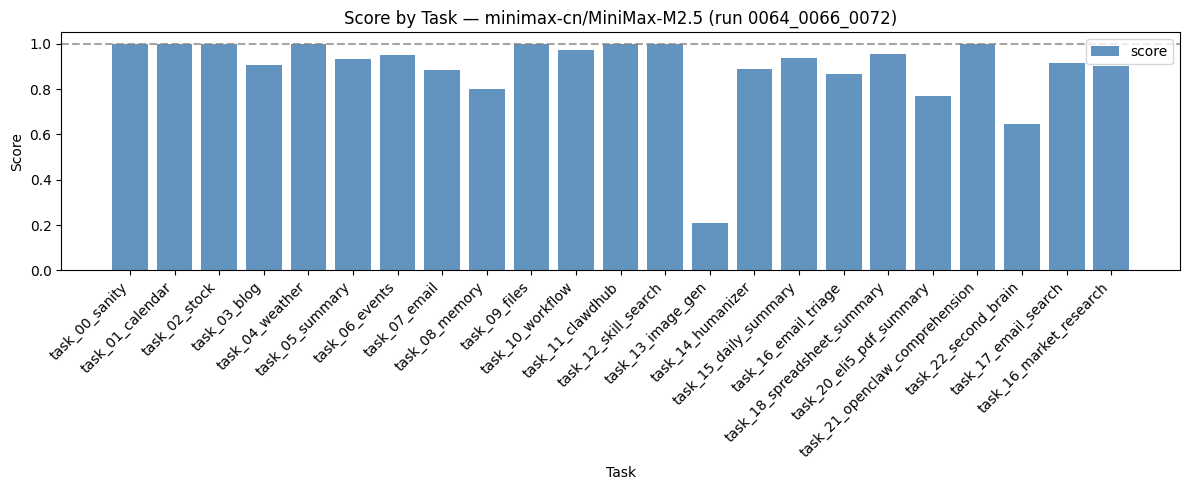

0.8924565217391303


In [8]:
# 图1：各任务得分（按 task）
fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(task_ids))
bars = ax.bar(x, scores, color="steelblue", alpha=0.85, label="score")
ax.axhline(y=1.0, color="gray", linestyle="--", alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(task_ids, rotation=45, ha="right")
ax.set_ylabel("Score")
ax.set_xlabel("Task")
ax.set_title(f"Score by Task — {model} (run {run_id})")
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()
print(sum(scores)/len(scores))

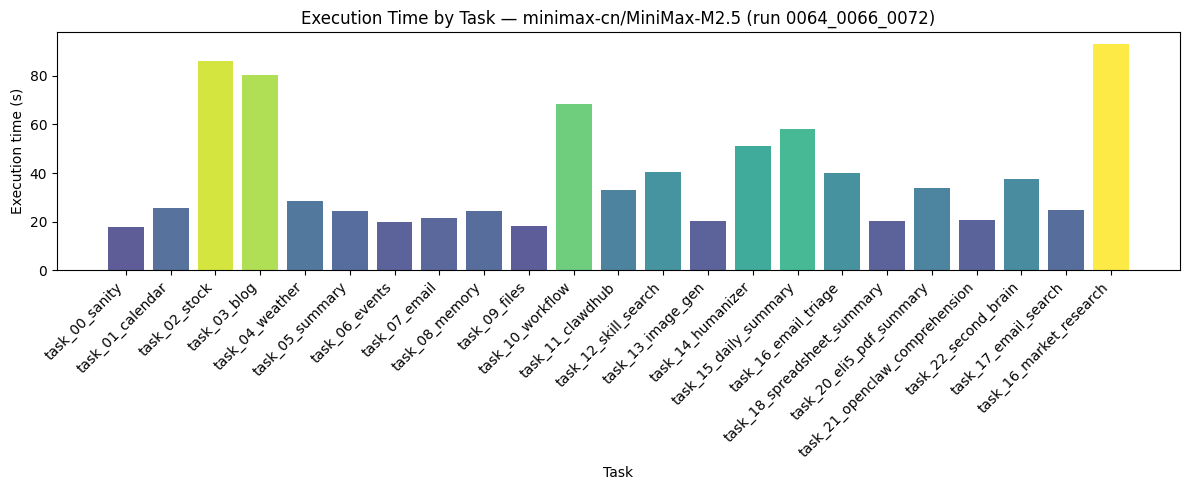

In [9]:
# 图2：各任务耗时（秒）
fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.viridis([t / max(times) if max(times) > 0 else 0 for t in times])
ax.bar(x, times, color=colors, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(task_ids, rotation=45, ha="right")
ax.set_ylabel("Execution time (s)")
ax.set_xlabel("Task")
ax.set_title(f"Execution Time by Task — {model} (run {run_id})")
plt.tight_layout()
plt.show()

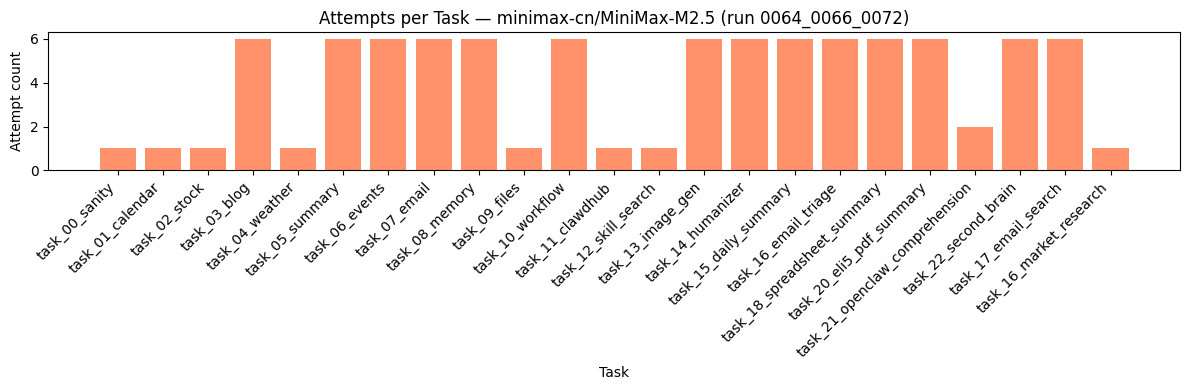

In [10]:
# 图3：各任务 attempt 次数
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x, attempt_counts, color="coral", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(task_ids, rotation=45, ha="right")
ax.set_ylabel("Attempt count")
ax.set_xlabel("Task")
ax.set_title(f"Attempts per Task — {model} (run {run_id})")
plt.tight_layout()
plt.show()

## 9.1.3 Qualitative Mechanisms: Why Some Tasks Recover and Others Do Not

第三层不再只看 success rate，而是解释为什么当前数据中几乎没有出现“小模型通过迭代追上大模型”的现象，并把这组实验里值得记录的额外发现一并写清楚。

### A. 反直觉主发现：iteration 没有缩小 gap，反而放大了 gap

最核心、也最反直觉的发现是：

- 首轮 gap 只有 `14.3pp`
- 引入 feedback-driven iteration 后，final gap 扩大到 `38.1pp`
- 也就是说，**迭代本身不是天然偏向小模型的补偿机制**；在这组数据里，它更像是一个“能力放大器”，让更强模型更能把反馈转化为新增成功

这意味着，不能把“允许 retry”默认理解成“便宜模型更占便宜”。如果模型本身具备更强的错误定位、计划修正和多约束重整能力，那么 feedback 反而会进一步拉开与小模型的差距。

### B. 额外发现 1：真正的分水岭不是首轮，而是“能不能把 feedback 变成新增成功”

只看 first-attempt，会觉得两者差距还不算特别大：

- MiniMax 首轮 `33.3%`
- GPT 首轮 `47.6%`

但一旦看迭代后的新增成功数，差异立刻变得非常明显：

- MiniMax 只新增 **1** 个成功任务
- GPT 新增 **6** 个成功任务

因此，这组数据提示我们：RQ1 不应只分析“谁 first attempt 更强”，还要分析“谁具备更高的 feedback conversion rate”。从这个角度看，GPT-5.3 的优势主要不是初始领先 3 个任务，而是后续又继续拉开了 5 个任务。

### C. 额外发现 2：小模型不是完全不会，而是大量停在 near-miss 区间

一个重要的次级发现是，MiniMax 在很多失败任务上并非低分崩溃，而是长期停在 `0.90+`、`0.95-` 的高分区：

- `task_10_workflow`：`0.9635 -> 0.9725`
- `task_18_spreadsheet_summary`：长期约 `0.96`
- `task_05_summary`：长期 `0.9325`
- `task_15_daily_summary`：`0.835 -> 0.935`
- `task_03_blog`：多轮 `0.91-0.94`

这说明两件事：

- 小模型往往能理解任务大意，也能在反馈下做局部修正
- 但它缺少最后那一步“把多个剩余缺陷同时清零”的能力

所以这里不是简单的“会”或“不会”，而是明显存在一个 **near-miss plateau**。这对后续 RQ2 很重要，因为它意味着不少额外 token 花在了“接近成功但始终不过线”的重复优化上。

### D. 额外发现 3：iteration 的收益窗口对小模型非常短，对大模型更长

从 `success@k` 可以看到，小模型和大模型的收益曲线形状不同：

- MiniMax 在 `k=2` 后就基本停止增长：`33.3% -> 38.1% -> 38.1% -> ...`
- GPT 在 `k=4` 前都还在增长：`47.6% -> 61.9% -> 71.4% -> 76.2%`

这说明：

- 对 MiniMax 来说，超过第 2 次 attempt 后，继续 retry 的边际收益非常低
- 对 GPT 来说，后续几轮 retry 仍然能系统性地产出新增成功

因此，retry budget 不应该被视为对所有模型都“等价公平”的资源。相同的 retry budget，实际上让强模型拿到了更多可兑现的 improvement。

### E. 额外发现 4：feedback 更擅长修复“局部错误”，不擅长突破“整体质量天花板”

`task_21_openclaw_comprehension` 展示了 feedback 有效的条件：

- 第 1 轮已经接近完成
- 错误范围小
- 修复目标明确
- 一次修改就能跨过阈值

而在以下任务中，feedback 的作用明显受限：

- `task_14_humanizer`
- `task_03_blog`
- `task_15_daily_summary`
- `task_16_email_triage`

这些任务更依赖：

- 全局结构重写
- 风格与语气控制
- 多文档综合与重点取舍
- 跨约束的整体协调

这提示一个更一般性的规律：**feedback 对“局部可验证错误”更有效，对“连续质量提升型任务”帮助有限**。因此，未来分析应该把任务区分为“validator-friendly”与“capability-bound”两类，而不是把所有 retry 效果混在一起看。

### F. 额外发现 5：有些失败并不是 search / tool failure，而是最后一公里的质量不过线

从执行状态看，很多 MiniMax 的 attempt 并不是 tool error、timeout 或 crash；它们往往显示为 `success`，只是最终评分未达 `1.0`。这点很关键：

- 失败并不总是来自不会调用工具
- 更常见的问题是输出已经成型，但质量、完整性、准确性或风格仍差一点

这意味着，在 agent setting 下，“执行成功”与“任务成功”之间存在明确鸿沟。对于小模型，这个鸿沟并不会因为多几轮 retry 自动消失。

### G. 额外发现 6：pass/fail 阈值把模型差异放大成了离散结果

从分数轨迹看，MiniMax 和 GPT 的很多差异其实先表现为小幅连续分差，最后才在 `pass@1.0` 口径下变成显著的离散差距。例如：

- `task_18_spreadsheet_summary`：MiniMax 约 `0.96`，GPT 最终 `1.0`
- `task_10_workflow`：MiniMax `0.9725`，GPT `1.0`
- `task_05_summary`：MiniMax `0.9325`，GPT `1.0`

这带来一个方法论上的发现：

- 若只看 binary success，会得到“差距很大”的结论
- 若结合连续 score 轨迹，则会发现小模型很多时候是在“接近通过但始终越不过线”

因此，RQ1 的分析除了 success rate，也应该持续报告 score trajectory，否则会低估 near-miss 现象的重要性。

### H. 额外发现 7：任务类型差异存在，但不是“某一类任务普遍帮助小模型追赶”

当前样本下，没有看到某个 category 出现系统性的 gap closure。更常见的模式是：

- `research`、`data_analysis`、`organization`、`complex` 等类别中，GPT 在 retry 后继续增长，而 MiniMax 不增长
- `comprehension` 是唯一出现 MiniMax 被明确修复的类别，但总体也没有实现对 GPT 的追平

这说明，至少在这个数据规模上，我们不能得出“某类任务天然更适合小模型靠 iteration 追赶”的强结论。更稳妥的说法是：**只有当错误足够局部、反馈足够可执行时，小模型才偶尔能追上；这更像 error-type effect，而不只是 task-category effect。**

### I. 额外发现 8：当前结果更像是在揭示“反馈利用能力”差异，而不只是基础能力差异

一个值得单独提出的 insight 是：

- 首轮成功率衡量的是初始任务完成能力
- 多轮后的增量成功率，更接近衡量模型的 **feedback utilization ability**

在这个指标上，GPT-5.3 显著更强。也就是说，这组实验除了比较“谁更会做题”，还比较出了“谁更会根据判错信息改题”。这可能是 agent benchmark 中一个被低估的能力维度。

### J. 额外发现 9：这组结果对论文叙事的启发是，RQ1 应从“是否追上”转为“何时追上、何时失效”

如果继续沿用“小模型能否追上大模型”作为单一叙事，当前结果会显得偏负面；但更有价值的做法是把问题写得更机制化：

1. 什么时候 feedback 能修复小模型的错误？
2. 什么时候反馈只会让小模型停留在 near-miss plateau？
3. 什么时候 iteration 会优先放大大模型优势？

这样，RQ1 就不只是一个 yes/no 问题，而是一个关于 **gap dynamics** 和 **feedback effectiveness boundary** 的问题。

## Expanded Takeaways for RQ1

除了“这是一个反直觉发现”之外，这组数据至少还支持以下结论：

- iteration 的价值并不对称；同样的反馈机制，对强模型的增益可能更大
- 首轮差距不是唯一关键，feedback 转化率才是决定最终差距的核心变量
- 小模型的大量失败并不是彻底失败，而是高分停滞的 near-miss
- retry 对小模型的有效窗口很短，超过前两轮后边际收益迅速衰减
- 局部、可验证、可执行的错误更容易被 feedback 修复；开放式、高质量综合任务更容易暴露能力上限
- 只看 binary success 会掩盖很多接近过线但始终不过线的现象，因此需要同时报告连续 score
- 这组结果更适合支持“反馈利用能力差异”这个新视角，而不是简单支持“便宜模型能靠 retry 追上贵模型”

## RQ1 Takeaway

基于这组 MiniMax-M2.5 vs GPT-5.3 的结果，RQ1 的结论应该改写为更谨慎、也更符合数据的版本：

- 小模型的首轮弱势确实存在，但 **首轮 gap 并不是主要问题**；更关键的是谁能持续把 feedback 转化为新增成功
- 在当前 21 个共同任务上，iteration **没有帮助 MiniMax 缩小** 与 GPT-5.3 的 performance gap，反而让 gap 从 `14.3pp` 扩大到 `38.1pp`
- feedback-driven iteration 对小模型并非完全无效，但目前只在少数“局部可修复错误”上有效
- 一旦任务依赖开放式综合、风格控制、复杂规划或多处残余错误的联合修复，小模型更容易进入高分停滞区，而大模型仍能继续把 near-miss 推到 pass

因此，这个 notebook 后续的图表与表格不应再服务于“证明小模型一定能追上”，而应服务于一个更扎实的分析框架：

1. first-attempt gap 是否存在；
2. gap 在 retry 中是收敛还是发散；
3. 哪些任务属于可恢复错误，哪些任务暴露了能力上限；
4. 模型之间的 feedback utilization ability 有何差异。



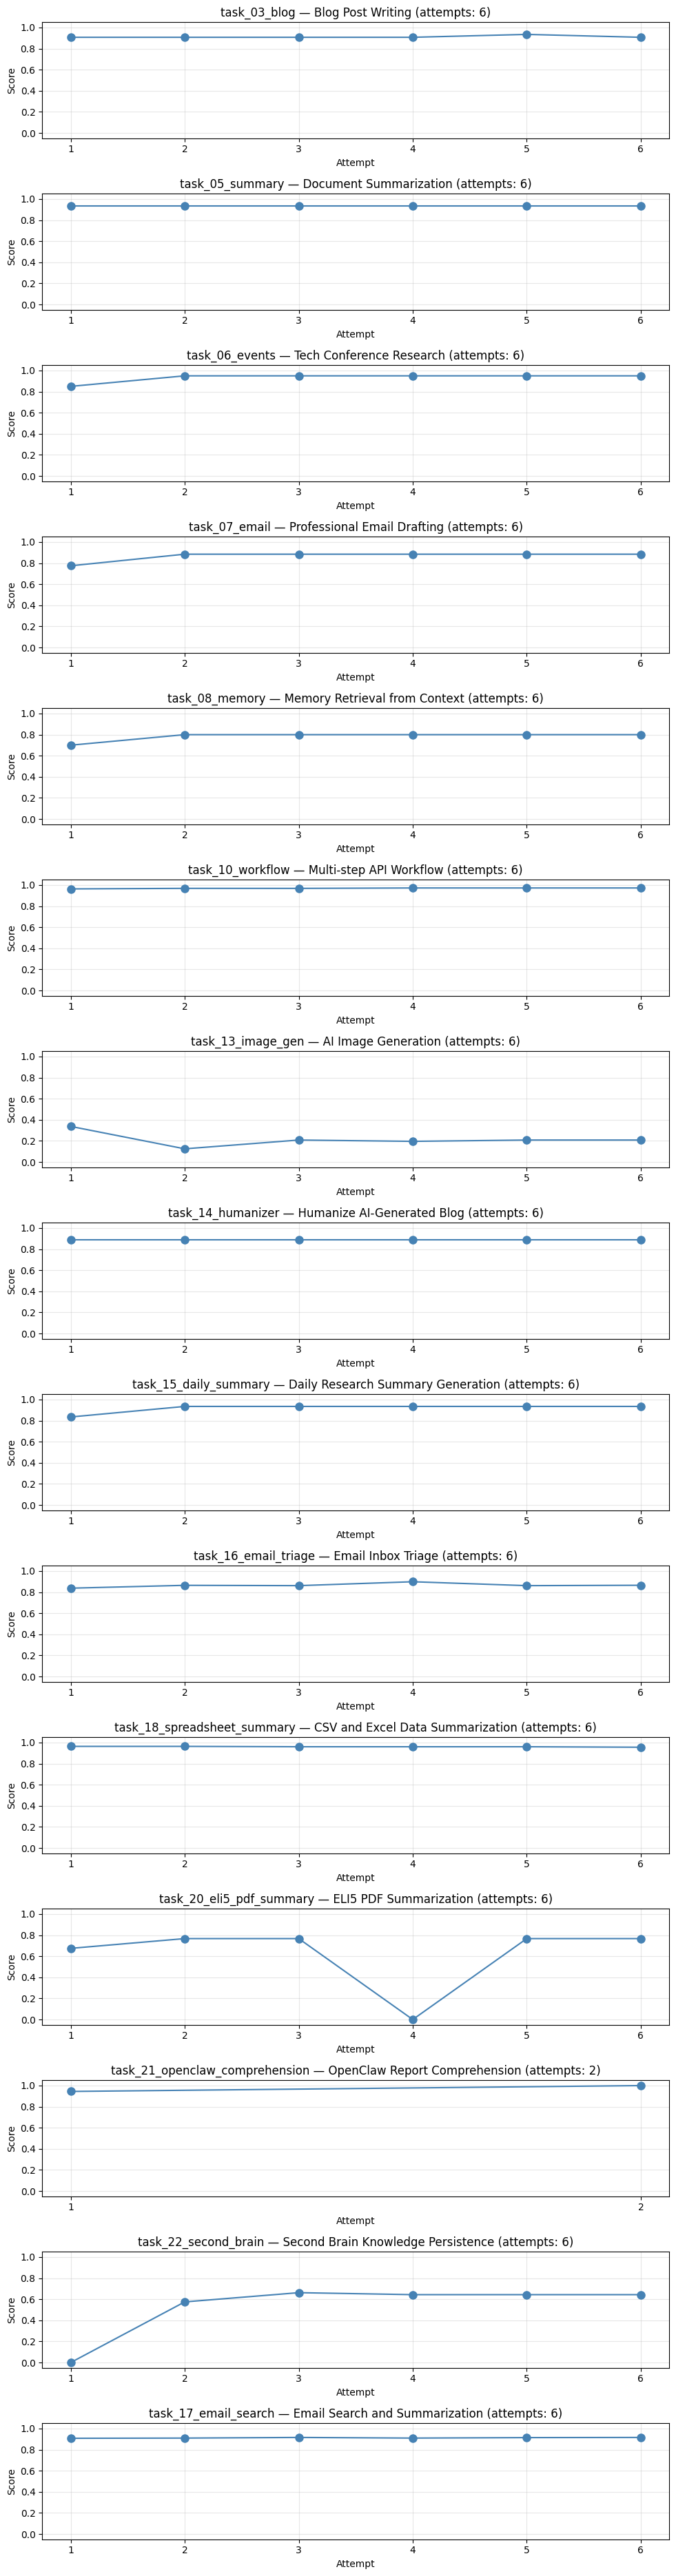

In [11]:
# 汇总每个 task 的每一轮 attempt：得分、耗时、状态
attempt_rows = []
for r in rows:
    for a in r["attempts"]:
        attempt_rows.append({
            "task_id": r["task_id"],
            "name": r["name"],
            "attempt": a["attempt"],
            "score": a["score"],
            "max_score": a["max_score"],
            "execution_time": a["execution_time"],
            "status": a["status"],
        })

# 仅多 attempt 的 task：画 尝试序号 vs 得分
multi = [r for r in rows if r["attempt_count"] > 1]
if not multi:
    print("没有多轮 attempt 的 task。")
else:
    fig, axes = plt.subplots(len(multi), 1, figsize=(10, 2.5 * len(multi)), sharex=False)
    if len(multi) == 1:
        axes = [axes]
    for i, r in enumerate(multi):
        ax = axes[i]
        atts = r["attempts"]
        nums = [x["attempt"] for x in atts]
        scs = [x["score"] for x in atts]
        ax.plot(nums, scs, "o-", color="steelblue", markersize=8)
        ax.set_ylabel("Score")
        ax.set_xlabel("Attempt")
        ax.set_title(f"{r['task_id']} — {r['name']} (attempts: {r['attempt_count']})")
        ax.set_ylim(-0.05, 1.05)
        ax.set_xticks(nums)
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [12]:
# 表：每个 task 的每一轮 attempt（得分 + 耗时）
if attempt_rows:
    try:
        import pandas as pd
        df = pd.DataFrame(attempt_rows)
        df["score_pct"] = (df["score"] / df["max_score"].replace(0, 1) * 100).round(1)
        display(df[["task_id", "attempt", "score", "max_score", "score_pct", "execution_time", "status"]])
    except Exception:
        for row in attempt_rows[:20]:
            print(row)
        if len(attempt_rows) > 20:
            print("...", len(attempt_rows) - 20, "more rows")

,task_id,attempt,score,max_score,score_pct,execution_time,status
0,task_00_sanity,1,1.0000,1.0,100.0,17.853824,success
1,task_01_calendar,1,1.0000,1.0,100.0,25.826634,success
2,task_02_stock,1,1.0000,1.0,100.0,86.028892,success
3,task_03_blog,1,0.9075,1.0,90.8,36.904215,success
4,task_03_blog,2,0.9075,1.0,90.8,2.308990,success
...,...,...,...,...,...,...,...
89,task_17_email_search,3,0.9160,1.0,91.6,-39.418853,success
90,task_17_email_search,4,0.9100,1.0,91.0,22.201181,success
91,task_17_email_search,5,0.9145,1.0,91.4,-66.600903,success
92,task_17_email_search,6,0.9160,1.0,91.6,1.495772,success


In [13]:
# 本 run 效率汇总（来自 JSON 顶层 efficiency）
for k, v in (efficiency or {}).items():
    if k != "per_task":
        print(f"  {k}: {v}")

  total_tokens: 8859695
  total_input_tokens: 3360921
  total_output_tokens: 104007
  total_cost_usd: 0.0
  total_requests: 408
  total_execution_time_seconds: 888.69
  tasks_with_usage_data: 23
  tokens_per_task: 1721600.5
  cost_per_task_usd: 0.0
  score_per_1k_tokens: 0.01188
  score_per_dollar: None
  success_rate: 1.189394
  success_per_1k_tokens: 0.0056879999999999995
  success_per_dollar: None


在这套评测里，execution.status = success 只说明 agent 执行成功了，不代表 completion.score = 1.0。
  judge 还会继续检查内容质量。结合这次数据，差一点通常是下面几类。

  task_06_events
  在 MiniMax 里，文件写出来了，5 个会议信息也基本找到了，所以执行是成功的；但 judge 仍只给 0.95。原因
  写得很直接：早期依赖了不够权威的二手来源，有些日期一开始带推断成分，后来虽然修正了不少，但整体仍被扣
  了“信息准确性”分。这类任务里，差一点通常是“信息源不够硬”或“验证不够彻底”。

  task_15_daily_summary
  这个任务 MiniMax 最终到 0.935，已经是很高分。judge 的意见是：内容覆盖、结构、优先级都很好，但表格栏
  位还能更清楚，视觉格式有轻微不一致。这说明它不是没做，而是交付质量还没到“无明显瑕疵”的程度。也就是
  executive summary 做出来了，但排版、信息组织、表达一致性还有小问题。

  task_14_humanizer
  MiniMax 六轮都停在 0.887。judge 认为文章已经明显比原文自然，很多要求都做到了，但仍残留一点“corporate
  residue”，比如某些标题或表达方式还不够像真人写的。也就是说，文件完成了、改写也完成了，但风格纯度不
  够，所以不给满分。

  task_05_summary、task_10_workflow、task_18_spreadsheet_summary
  这些任务更典型地体现“接近正确但不是完全正确”。分数都在 0.93-0.97 左右，说明大部分约束都满足了，但还
  残留一两个 judge 认为关键的遗漏、轻微错误，或者没有完全满足格式/逻辑要求。对于二元通过标准来说，只要
  还留着这些尾巴，就还是 fail。

  所以 judge 不给满分，通常不是因为：

  - 没有产出结果
  - 不会用工具
  - 完全答非所问

  而更常见的是：

  - 信息准确但没完全验证到位
  - 主要内容都有，但少了个别关键点
  - 结构基本对，但优先级或组织还不够好
  - 文风大体符合，但不够彻底
  - 输出能用，但还没达到 benchmark 要求的“完全满足”

  这也是为什么我说它是 near-miss plateau：不是不会做，而是总有最后 5%-10% 的残余问题清不干净。

  如果你要，我可以把这 21 个共同任务里 MiniMax 所有“高分但失败”的 judge notes 全部整理成一个表，按“准
  确性/完整性/风格/组织/格式”分类给你。

In [ ]:
# 每个模型的总体成本、成功成本、失败成本，以及成功任务平均成本（人民币）
import json
from pathlib import Path
import pandas as pd

MINIMAX_STANDARD_PRICE_CNY_PER_MTOKEN = {
    "input_tokens": 2.1,
    "output_tokens": 8.4,
    "cache_read_tokens": 0.21,
    "cache_write_tokens": 2.625,
}
MINIMAX_MEMBER_PRICE_CNY_PER_MTOKEN = {
    "input_tokens": 1.260,
    "output_tokens": 5.040,
    "cache_read_tokens": 0.252,
    "cache_write_tokens": 1.260,
}
MINIMAX_PRICING_MODE = "member"  # one of: 'standard', 'member'
MINIMAX_PRICE_OPTIONS = {
    "standard": MINIMAX_STANDARD_PRICE_CNY_PER_MTOKEN,
    "member": MINIMAX_MEMBER_PRICE_CNY_PER_MTOKEN,
}
if MINIMAX_PRICING_MODE not in MINIMAX_PRICE_OPTIONS:
    raise ValueError(f"Unsupported MINIMAX_PRICING_MODE: {MINIMAX_PRICING_MODE}")
ACTIVE_MINIMAX_PRICE_CNY_PER_MTOKEN = MINIMAX_PRICE_OPTIONS[MINIMAX_PRICING_MODE]
GPT53_PRICE_CNY_PER_MTOKEN = {
    "input_tokens": 6.125,
    "output_tokens": 49.0,
    "cache_read_tokens": 1.230,
    "cache_write_tokens": 0.0,
}
PRICE_CNY_PER_MTOKEN = {
    "MiniMax-M2.5": ACTIVE_MINIMAX_PRICE_CNY_PER_MTOKEN,
    "GPT-5.3": GPT53_PRICE_CNY_PER_MTOKEN,
}

MODEL_RESULTS = {
    "MiniMax-M2.5": Path(RESULTS_PATH_MINIMAX2_5),
    "GPT-5.3": Path(RESULTS_PATH_GPT5_3),
}
print(f"MiniMax pricing mode: {MINIMAX_PRICING_MODE}")
print(f"MiniMax price table: {ACTIVE_MINIMAX_PRICE_CNY_PER_MTOKEN}")
print(f"GPT price table: {GPT53_PRICE_CNY_PER_MTOKEN}")

def _compute_task_cost_cny(task, prices):
    total = 0.0
    for attempt in task.get("attempts") or []:
        usage = ((attempt.get("execution") or {}).get("usage") or attempt.get("usage") or {})
        total += float(usage.get("input_tokens") or 0) / 1_000_000 * prices["input_tokens"]
        total += float(usage.get("output_tokens") or 0) / 1_000_000 * prices["output_tokens"]
        total += float(usage.get("cache_read_tokens") or 0) / 1_000_000 * prices["cache_read_tokens"]
        total += float(usage.get("cache_write_tokens") or 0) / 1_000_000 * prices["cache_write_tokens"]
    return total

cost_summary_rows = []
for model_name, result_path in MODEL_RESULTS.items():
    data = json.loads(result_path.read_text(encoding="utf-8"))
    prices = PRICE_CNY_PER_MTOKEN[model_name]

    overall_total_cost_cny = 0.0
    success_cost_cny = 0.0
    failed_cost_cny = 0.0
    success_task_count = 0

    for task in data.get("tasks") or []:
        task_cost_cny = _compute_task_cost_cny(task, prices)
        overall_total_cost_cny += task_cost_cny

        grading = task.get("grading") or {}
        score = float(grading.get("score") or 0)
        max_score = float(grading.get("max_score") or 1)
        task_success = max_score > 0 and score >= max_score

        if task_success:
            success_cost_cny += task_cost_cny
            success_task_count += 1
        else:
            failed_cost_cny += task_cost_cny

    cost_summary_rows.append({
        "model": model_name,
        "overall_total_cost_cny": overall_total_cost_cny,
        "success_cost_cny": success_cost_cny,
        "failed_cost_cny": failed_cost_cny,
        "success_task_count": success_task_count,
        "cost_per_success_task_cny": success_cost_cny / success_task_count if success_task_count else 0.0,
    })

cost_summary_df = pd.DataFrame(cost_summary_rows)
try:
    display(cost_summary_df.round(4))
except NameError:
    print(cost_summary_df.round(4).to_string(index=False))
